# Importar pacotes

In [46]:
from statsmodels.tsa.deterministic import CalendarFourier, DeterministicProcess,Fourier
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, root_mean_squared_error

from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, ElasticNet, Lasso, Ridge
from sklearn.neural_network import MLPRegressor

from sklearn.ensemble import ExtraTreesRegressor, RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.neighbors import KNeighborsRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import TimeSeriesSplit

# Métodos utilitários

In [4]:
from utils.common import import_dataframe
from utils.common import make_lags, make_leads
from utils.common import calculate_metrics
from utils.common import HybridRecursive, HybridBase
from utils.common import ModeloPrevisaoVolume

# Importação dos dados

In [5]:
nome_coluna_volume = "Volume Útil Armazenado (%)"
nome_coluna_vazao_natural = "Vazão Natural (m³/s)"
nome_coluna_vazao_jusante = "Vazão Jusante (m³/s)"

df = import_dataframe()
df.set_index("Data", inplace=True)
df = df[df.index >= "2018-01-01"]


# Construção - Vazão Natural  e Juzante

In [4]:

VALIDATION_SIZE = 1*90

def vazao_dados(df, nome_coluna_vazao):
  y_vazao = df[nome_coluna_vazao]
  fourier = CalendarFourier(freq="YE", order=2)
  y_vazao = y_vazao.asfreq("D")
  dp = DeterministicProcess(
    index=y_vazao.index,
    constant=False,
    order=1,
    seasonal=False,
    additional_terms=[fourier],
    drop=True,
  )
  
  X_full_vazao = dp.in_sample()
  return X_full_vazao, y_vazao

X_j, y_j = vazao_dados(df, nome_coluna_vazao_jusante)
X_n, y_n = vazao_dados(df, nome_coluna_vazao_natural)
df_aux = pd.concat([pd.DataFrame(X_j).add_suffix('_jusante'),
                    pd.DataFrame(X_n).add_suffix('_natural'),
                    y_n, y_j], axis=1)


In [5]:
#### DENTRO DO FOR PORQUE FAZ AUTOREGRESSÃO -> SO VALE PARA TREINO. 
def volume_dados(df, y_vn, y_vj, TARGET_COLUMN_NAME = 'Volume Útil Armazenado (%)'):
  y_vol = df[TARGET_COLUMN_NAME]
  X_lags = make_lags(y_vol.squeeze(), 1)
  X_Qin_leads = make_leads(y_vn.squeeze(), 1, name="Qin")
  X_Qout_leads = make_leads(y_vj.squeeze(), 1, name="Qout")
  X_full_vol = pd.concat([X_lags, X_Qin_leads, X_Qout_leads], axis=1).dropna()
  y_vol, X_full_vol = y_vol.align(X_full_vol, join='inner', axis=0)
  return X_full_vol, y_vol


## Treino

In [ ]:
N_SPLITS = 5
FORECAST_HORIZON = VALIDATION_SIZE
tscv = TimeSeriesSplit(
    n_splits=N_SPLITS,
    test_size=FORECAST_HORIZON,
    gap=0 # Sem gap entre treino e teste
)

all_preds_model = []
all_y_test = []
lista_modelos_v = [LinearRegression(fit_intercept=False)]
lista_modelos_j = [HybridRecursive(LinearRegression(), RandomForestRegressor(), lags=2) for i in range(0, len(lista_modelos_v))]
lista_modelos_n = [HybridRecursive(Lasso(), KNeighborsRegressor(), lags=2) for i in range(0, len(lista_modelos_v))]



#### FOR PARA CADA MODELO A SER TESTADO ###
for pos, modelo_v in enumerate(lista_modelos_v):

    model = ModeloPrevisaoVolume(modelo_v, usar_jusante=True,
                                modelo_vazao_juzante = lista_modelos_j[pos],
                                modelo_vazao_natural = lista_modelos_n[pos])


#### DENTRO DE UM FOR PARA CADA SPLIT DO TIME SERIES SPLIT ####
    for fold, (train_idx, test_idx) in enumerate(tscv.split(df)):
    
        df_train = df.iloc[train_idx]
        df_test = df.iloc[test_idx]
        df_aux_train = df_aux.iloc[train_idx]
        df_aux_test = df_aux.iloc[test_idx]        
        X_full_vol_train, y_vol_train = volume_dados(df_train, y_n, y_j)

        model.fit_vazao_jusante(df_aux_train.filter(like='jusante'), y_j.loc[df_aux_train.index])
        model.calculate_lags(df_aux_test.filter(like='jusante'))
        y_pred_train_vj = model.predict(df_aux_train.filter(like='jusante'))
        y_pred_test_vj = model.predict(df_aux_test.filter(like='jusante'))

        model.fit_vazao_natural(df_aux_test.filter(like='natural'), y_n.loc[df_aux_train.index])
        model.calculate_lags(df_aux_test.filter(like='natural'))
        y_pred_train_vn = model.predict(df_aux_train.filter(like='natural'))
        y_pred_test_vn = model.predict(df_aux_test.filter(like='natural'))
        
        model.fit(X_full_vol_train, y_vol_train)

        #### VAI FAZER O CALCULO E SALVAR A METRICA ####
        
        
        

PARA DESACOPLAR

Usar modelos separados.

1) Criar função Calculate lags independente de modelo ou de qualquer coisa (SEM CLASSE).
2) Fazer para cada tipo (VAZAO PRIMEIRO) o fit do modelo 1 (que considera sazonalidade e tendencia)
3) Fazer o predict deste modelo
4) Fazer yreal - y_pred (para calcular o ciclo Lag2), pegar o modelo 2 e fazer fit dele considerando lag do residuo.
5) Obter o valor predito final y_pred_final -> somando y_pred + y_pred_residuo
6) Pegar o y_pred_final (da vazao) e unir com o y_pred_final da outra vazao e usar o lag do volume como variáveis do modelo de volume que faz fit e predict.
OBS: O MODELO É RECURSIVO

In [6]:
def calculate_lags_treino(df_aux, column, lags = 1,):
    df_aux_lags = df_aux[column].shift(lags).rename(f"{column}_lag{lags}")
    df_aux_lags = df_aux_lags.fillna(method='ffill').fillna(method='bfill')
    df_ = pd.concat([df_aux, df_aux_lags], axis=1)
    return df_




Iniciando Validação Cruzada...

Fold 1: Treino até 2024-09-12 | Teste de 2024-09-13 a 2024-12-11
RMSE Fold 1: 1.2494
MAE Fold 1: 0.9971
------------------------------


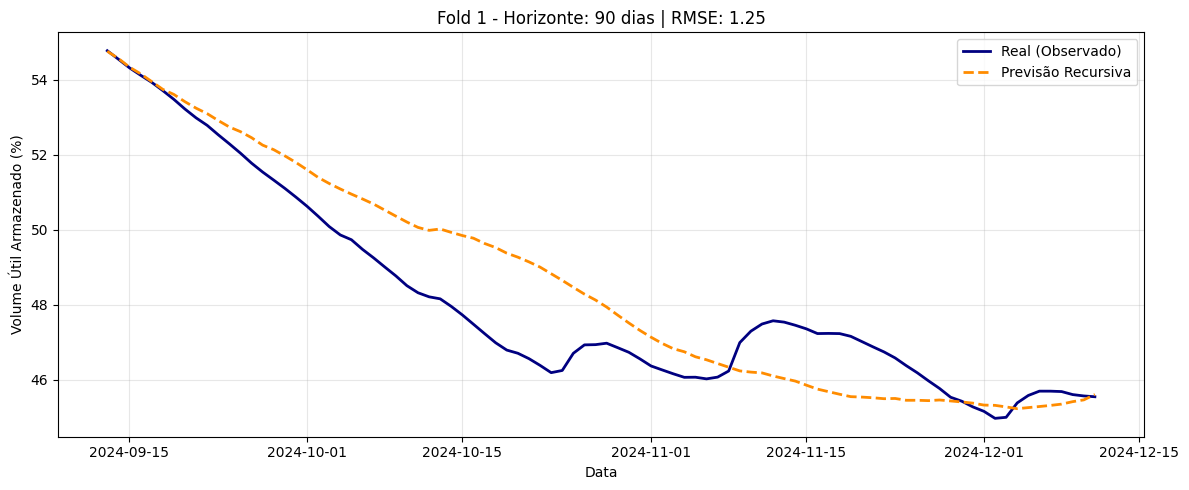

------------------------------
Fold 2: Treino até 2024-12-11 | Teste de 2024-12-12 a 2025-03-11
RMSE Fold 2: 1.5254
MAE Fold 2: 1.2650
------------------------------


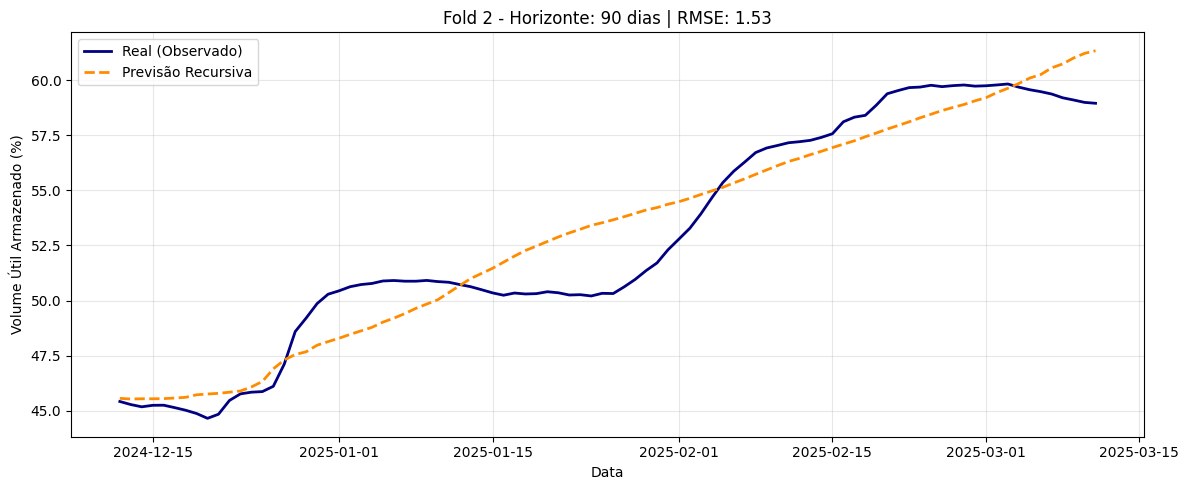

------------------------------
Fold 3: Treino até 2025-03-11 | Teste de 2025-03-12 a 2025-06-09
RMSE Fold 3: 2.6759
MAE Fold 3: 1.9065
------------------------------


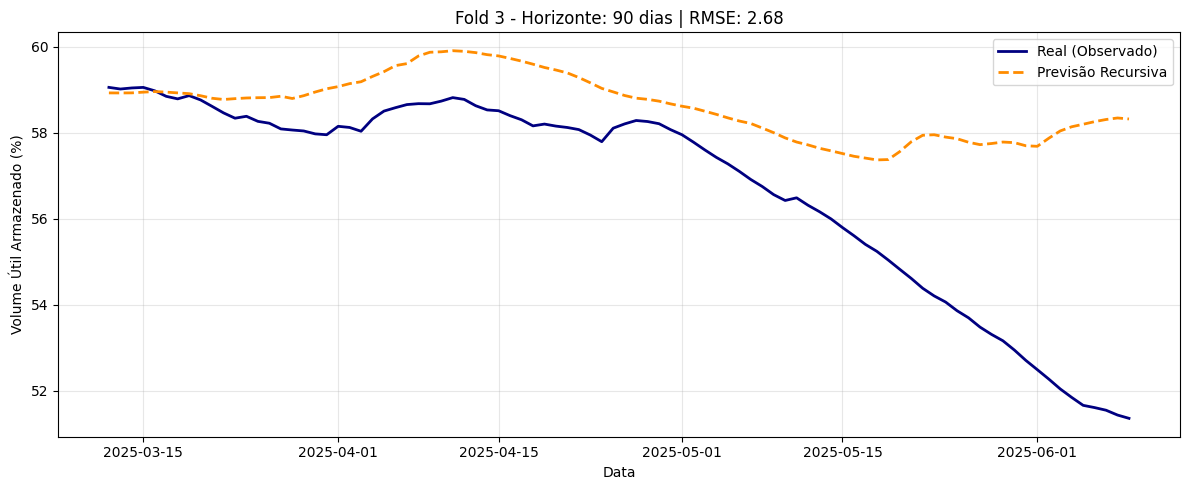

------------------------------
Fold 4: Treino até 2025-06-09 | Teste de 2025-06-10 a 2025-09-07
RMSE Fold 4: 7.3773
MAE Fold 4: 6.4322
------------------------------


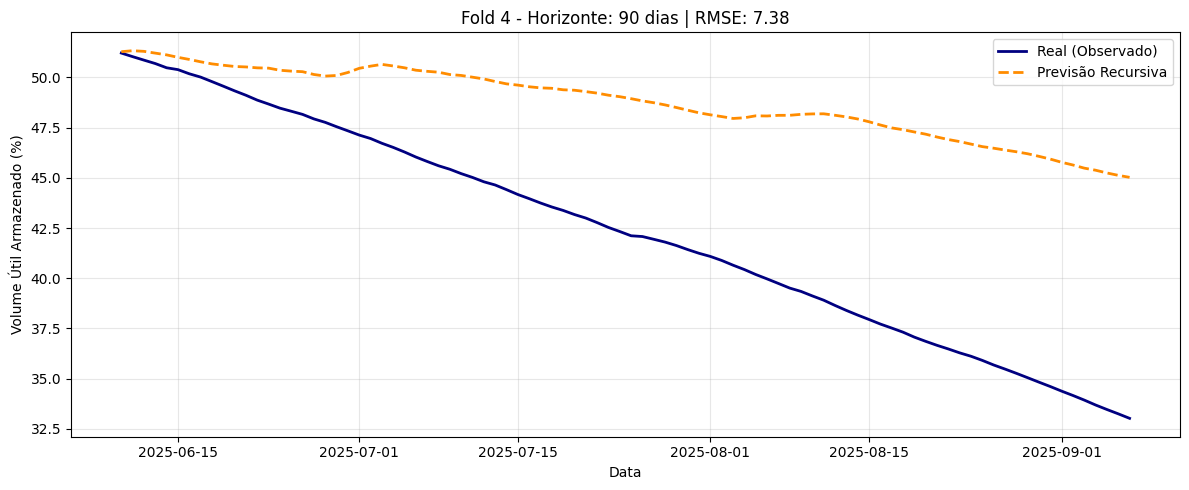

------------------------------
Fold 5: Treino até 2025-09-07 | Teste de 2025-09-08 a 2025-12-06
RMSE Fold 5: 5.3875
MAE Fold 5: 4.9430
------------------------------


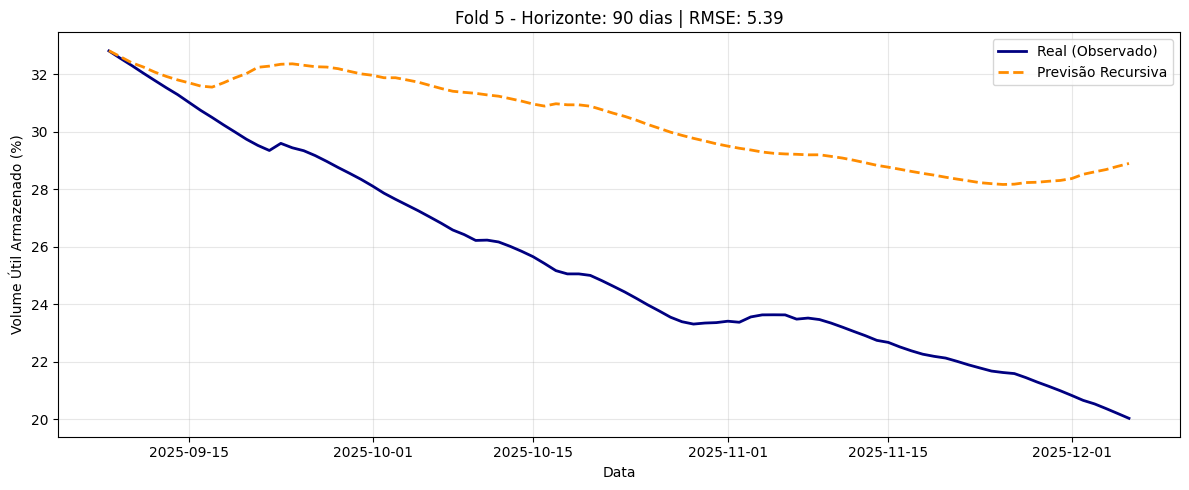

------------------------------

RMSE Médio: 3.6431


In [64]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import TimeSeriesSplit
from statsmodels.tsa.deterministic import CalendarFourier, DeterministicProcess
from sklearn.metrics import mean_squared_error
import warnings
import matplotlib.pyplot as plt

# Ignore warnings that match the specified criteria
warnings.filterwarnings('ignore', message='.*deprecated.*', category=DeprecationWarning)

# Issue a warning
warnings.warn('This is a deprecated feature', DeprecationWarning)

# --- 1. CONFIGURAÇÃO E DADOS ---
nome_coluna_volume = "Volume Útil Armazenado (%)"
nome_coluna_vazao_natural = "Vazão Natural (m³/s)"
nome_coluna_vazao_jusante = "Vazão Jusante (m³/s)"

df = import_dataframe()
df[(df['Data']<='2014-03-01')|(df['Data']>='2016-02-15')]
df.set_index("Data", inplace=True)
#(k['Data']<='2014-03-01')|(k['Data']>='2016-02-15')

#df = df[df.index >= "2018-01-01"]

VALIDATION_SIZE = 90
LAGS_VAZAO = 2
LAGS_VOLUME = 1

# --- 2. FUNÇÕES AUXILIARES (DESACOPLADAS) ---

def criar_features_deterministicas(index, order=2):
    """Cria X para sazonalidade e tendência (usado pelos modelos lineares de vazão)."""
    fourier = CalendarFourier(freq="YE", order=order)
    dp = DeterministicProcess(
        index=index,
        constant=True,
        order=1, # Tendência linear
        seasonal=False,
        additional_terms=[fourier],
        drop=True,
    )
    return dp.in_sample()

def criar_features_deterministicas_volume(index):
    dp = DeterministicProcess(
        index=index,
        constant=True, order=1,
        additional_terms=[
            Fourier(period=365.25 * 2, order=1),
            CalendarFourier(freq="YE", order=2)
        ],
        drop=True
    )
    return dp.in_sample()

def criar_lags(series, lags):
    """Cria DataFrame com lags para treino."""
    df_lags = pd.DataFrame(index=series.index)
    for lag in range(1, lags + 1):
        df_lags[f'lag_{lag}'] = series.shift(lag)
    return df_lags

def treinar_modelo_hibrido_vazao(y_train, modelo_trend, modelo_resid, lags):
    """
    Treina o combo: Modelo Linear (Tendência) + Modelo ML (Resíduos Lags).
    Retorna os modelos treinados e os últimos resíduos para iniciar o loop de teste.
    """
    # 1. Features Determinísticas
    X_trend = criar_features_deterministicas(y_train.index)
    
    # 2. Fit Modelo Tendência
    modelo_trend.fit(X_trend, y_train)
    y_pred_trend = modelo_trend.predict(X_trend)
    y_pred_trend = pd.Series(y_pred_trend, index=y_train.index)
    
    # 3. Calcular Resíduos
    residuos = y_train - y_pred_trend
    
    # 4. Criar Lags dos Resíduos para o Modelo 2
    X_resid = criar_lags(residuos, lags).dropna()
    y_resid_target = residuos.loc[X_resid.index]
    
    # 5. Fit Modelo Resíduo
    modelo_resid.fit(X_resid, y_resid_target)
    
    # Retorna modelos e os ultimos dados de residuos para servir de 'semente' no teste
    last_residuals = residuos.tail(lags).values
    
    return modelo_trend, modelo_resid, last_residuals

def treinar_modelo_volume(df_train, col_vol, col_vn, col_vj, model_vol):
    """
    Treina o modelo de volume usando:
    Target: Volume(t)
    Features: Volume(t-1), Vn(t), Vj(t)
    Nota: No treino usamos as vazões REAIS (Teacher Forcing).
    """
    y = df_train[col_vol]
    
    # Features
    X_dynamic = pd.DataFrame(index=df_train.index)
    X_dynamic['vol_lag1'] = df_train[col_vol].shift(1)
    X_dynamic['vazao_n'] = df_train[col_vn] # Vazão no dia atual (conforme pedido)
    X_dynamic['vazao_j'] = df_train[col_vj] # Vazão no dia atual
    

    X_trend = criar_features_deterministicas_volume(df_train.index)
    
    # Junta tudo (alinha pelo índice automaticamente)
    X_full = pd.concat([X_dynamic, X_trend], axis=1).dropna()
    
    # Alinha y com X (por causa dos NaNs do lag)
    y_train = y.loc[X_full.index]
    
    model_vol.fit(X_full, y_train)
    return model_vol



# --- 3. LOOP DE VALIDAÇÃO (TIME SERIES SPLIT) ---

tscv = TimeSeriesSplit(n_splits=5, test_size=VALIDATION_SIZE)

resultados = []

print("Iniciando Validação Cruzada...\n")

for fold, (train_idx, test_idx) in enumerate(tscv.split(df)):
    
    # Separação dos dados
    df_train = df.iloc[train_idx]
    df_test = df.iloc[test_idx]
    
    print(f"Fold {fold+1}: Treino até {df_train.index[-1].date()} | Teste de {df_test.index[0].date()} a {df_test.index[-1].date()}")

    # =================================================================
    # ETAPA 1: TREINAMENTO (Usando apenas dados de Treino)
    # =================================================================
    
    # --- A. Treinar Vazão Natural (Híbrido) ---
    model_trend_n = Lasso(alpha=0.1)
    model_resid_n = KNeighborsRegressor(n_neighbors=5)
    
    m_trend_n, m_resid_n, last_resids_n = treinar_modelo_hibrido_vazao(
        df_train[nome_coluna_vazao_natural], model_trend_n, model_resid_n, LAGS_VAZAO
    )
    
    # --- B. Treinar Vazão Jusante (Híbrido) ---
    model_trend_j = LinearRegression()
    model_resid_j = RandomForestRegressor(n_estimators=50, random_state=42)
    
    m_trend_j, m_resid_j, last_resids_j = treinar_modelo_hibrido_vazao(
        df_train[nome_coluna_vazao_jusante], model_trend_j, model_resid_j, LAGS_VAZAO
    )
    
    # --- C. Treinar Modelo de Volume ---
    # No treino, o modelo aprende a relação: Vol_t = f(Vol_t-1, Vn_t_real, Vj_t_real)
    model_volume = LinearRegression()
    #model_volume = MLPRegressor()
    model_volume = treinar_modelo_volume(
        df_train, nome_coluna_volume, nome_coluna_vazao_natural, nome_coluna_vazao_jusante, model_volume
    )

    # =================================================================
    # ETAPA 2: PREVISÃO RECURSIVA (Passo a passo no Teste)
    # =================================================================
    
    # Prepara as features determinísticas para TODO o período de teste (pois sabemos as datas)
    X_trend_test_n = criar_features_deterministicas(df_test.index)
    X_trend_test_j = criar_features_deterministicas(df_test.index)
    X_trend_test_v = criar_features_deterministicas_volume(df_test.index)
    
    # Inicializa históricos para a recursão
    # Precisamos do histórico de resíduos das vazões (buffer) e do último volume conhecido
    hist_resid_n = list(last_resids_n) # Ex: [resid_t-2, resid_t-1]
    hist_resid_j = list(last_resids_j)
    last_vol = df_train[nome_coluna_volume].iloc[-1] # Volume t-1 inicial
    
    preds_volume = []
    preds_vn = []
    preds_vj = []
    # Nomes das colunas de lag (para criar o DF certinho e calar o warning)
    cols_lags = [f'lag_{k}' for k in range(1, LAGS_VAZAO + 1)]
    
    # LOOP DIA A DIA (Aqui acontece a mágica recursiva)
    for i in range(len(df_test)):
        current_date = df_test.index[i]
        idx_atual = [df_test.index[i]]
        
        # --- 1. Prever Vazão Natural ---
        # Parte 1: Tendência (Determinística)
        trend_val_n = m_trend_n.predict(X_trend_test_n.iloc[[i]])[0]
        # Resíduo: CRIAR DATAFRAME COM NOMES DE COLUNAS
        vals_lags_n = np.array(hist_resid_n[-LAGS_VAZAO:][::-1])
        df_feat_resid_n = pd.DataFrame([vals_lags_n], columns=cols_lags, index=idx_atual)
        # Parte 2: Resíduo (Baseado nos lags anteriores previstos ou calculados)
        # Monta array de features [lag_1, lag_2] (invertendo a lista para ficar t-1, t-2)
        resid_pred_n = m_resid_n.predict(df_feat_resid_n)[0]
        
        # Valor Final
        y_pred_n = trend_val_n + resid_pred_n
        preds_vn.append(y_pred_n)
        
        # Atualiza histórico de resíduos (Assumimos que o resíduo "real" é o predito para continuar o loop s/ dados futuros)
        # Opcional: Se quiser atualizar com erro zero (puro autoregressivo), apenas appenda o predito.
        hist_resid_n.append(resid_pred_n) 
        
        # --- 2. Prever Vazão Jusante ---
        trend_val_j = m_trend_j.predict(X_trend_test_j.iloc[[i]])[0]
        vals_lags_j = np.array(hist_resid_j[-LAGS_VAZAO:][::-1])
        df_feat_resid_j = pd.DataFrame([vals_lags_j], columns=cols_lags, index=idx_atual)
        resid_pred_j = m_resid_j.predict(df_feat_resid_j)[0]
        
        y_pred_j = trend_val_j + resid_pred_j
        preds_vj.append(y_pred_j)
        hist_resid_j.append(resid_pred_j)
        
        # --- 3. Prever Volume ---
        # Features: [Vol_lag1, Vazao_N_pred, Vazao_J_pred]
        # Parte Dinâmica (calculada agora)
        df_dynamic = pd.DataFrame({
            'vol_lag1': [last_vol],
            'vazao_n': [y_pred_n],
            'vazao_j': [y_pred_j]
        }, index=idx_atual)
        
        # Parte Estática (já calculada antes, pegamos a linha 'i')
        # CORREÇÃO CRÍTICA: troquei iloc[[1]] por iloc[[i]]
        df_static = X_trend_test_v.iloc[[i]] 
        
        # Concatenar (Pandas alinha tudo e mantém os nomes das colunas originais)
        X_vol_input = pd.concat([df_dynamic, df_static], axis=1)
        
        vol_pred = model_volume.predict(X_vol_input)[0]
        preds_volume.append(vol_pred)
        
        # Atualiza o last_vol para o próximo passo ser o volume predito agora
        last_vol = vol_pred

    # =================================================================
    # ETAPA 3: AVALIAÇÃO
    # =================================================================
    y_true = df_test[nome_coluna_volume]
    rmse = np.sqrt(mean_squared_error(y_true, preds_volume))
    mae = np.mean(np.abs(y_true - preds_volume))
    resultados.append(rmse)
    print(f"RMSE Fold {fold+1}: {rmse:.4f}")
    print(f"MAE Fold {fold+1}: {mae:.4f}")
    print("-" * 30)
    # === PLOT DE CADA FOLD ===
    plt.figure(figsize=(12, 5))
    plt.plot(y_true.index, y_true, label='Real (Observado)', color='navy', linewidth=2)
    plt.plot(y_true.index, preds_volume, label='Previsão Recursiva', color='darkorange', linestyle='--', linewidth=2)
    
    plt.title(f'Fold {fold+1} - Horizonte: {VALIDATION_SIZE} dias | RMSE: {rmse:.2f}')
    plt.xlabel('Data')
    plt.ylabel(nome_coluna_volume)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show() # Exibe o gráfico antes de passar para o próximo fold
    
    print("-" * 30)

print(f"\nRMSE Médio: {np.mean(resultados):.4f}")

<Axes: xlabel='Data'>

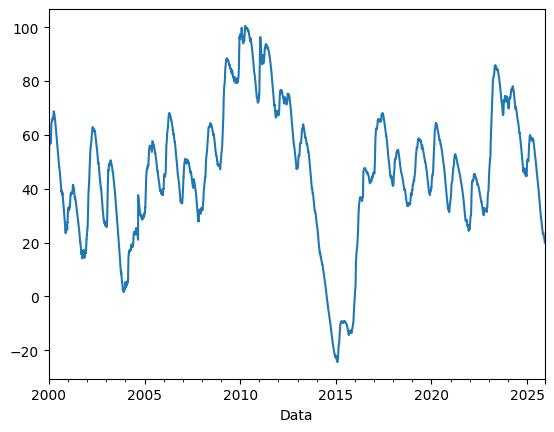

In [10]:
### Volume atual - Volume anterior -> Variação do volume
### Variação do Volume atual - Variação do Volume anterior -> Variação da variação do volume

df[nome_coluna_volume].plot()

<Axes: xlabel='Data'>

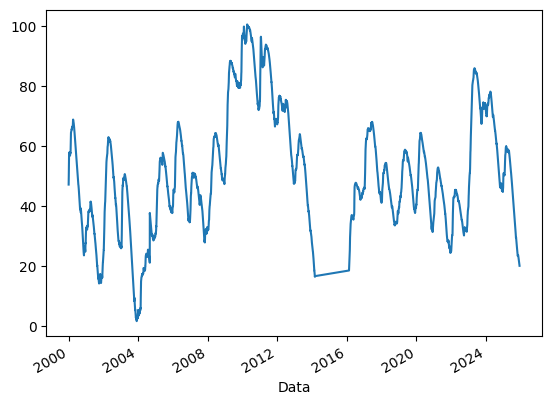

In [44]:
k = df.reset_index()
k = k[(k['Data']<='2014-03-01')|(k['Data']>='2016-02-15')]
k.set_index('Data', inplace = True)
k['Volume Útil Armazenado (%)'].plot()

In [34]:
df.reset_index()

,Data,Volume Útil Armazenado (%),Vazão Jusante (m³/s),Vazão Natural (m³/s),Data_num
0,2000-01-01,47.11254,10.16,70.885,0
1,2000-01-02,47.77519,10.18,94.864,1
2,2000-01-03,48.59438,7.29,108.208,2
3,2000-01-04,49.99680,6.34,162.936,3
4,2000-01-05,51.94578,6.33,211.604,4
...,...,...,...,...,...
9467,2025-12-02,20.66146,8.35,10.243,9467
9468,2025-12-03,20.53750,8.35,11.494,9468
9469,2025-12-04,20.37574,11.60,11.024,9469
9470,2025-12-05,20.20720,10.20,6.729,9470


Iniciando Validação Cruzada...

Fold 1: Treino até 2024-09-12 | Teste de 2024-09-13 a 2024-12-11
=== EQUAÇÃO DO MODELO LINEAR ===
Intercepto (Valor Base): -0.2636
------------------------------
              Variável  Peso (Coeficiente)
0             vol_lag1        9.986727e-01
1             vol_diff        2.582591e-02
10  cos(1,freq=YE-DEC)       -1.815370e-02
2            vol_diff2       -1.519604e-02
3              vazao_n        9.279555e-03
4              vazao_j       -8.385250e-03
7        sin(1,730.50)        6.248806e-03
8        cos(1,730.50)       -5.634840e-03
11  sin(2,freq=YE-DEC)        3.317169e-03
12  cos(2,freq=YE-DEC)       -8.251931e-04
9   sin(1,freq=YE-DEC)       -6.715028e-04
6                trend        1.720703e-05
5                const       -7.806256e-18
------------------------------

Fórmula aproximada:
Y = -0.2636 + (0.9987 * vol_lag1) + (0.0258 * vol_diff) - (0.0152 * vol_diff2) + (0.0093 * vazao_n) - (0.0084 * vazao_j) - (0.0000 * const) + (0.0000 * 

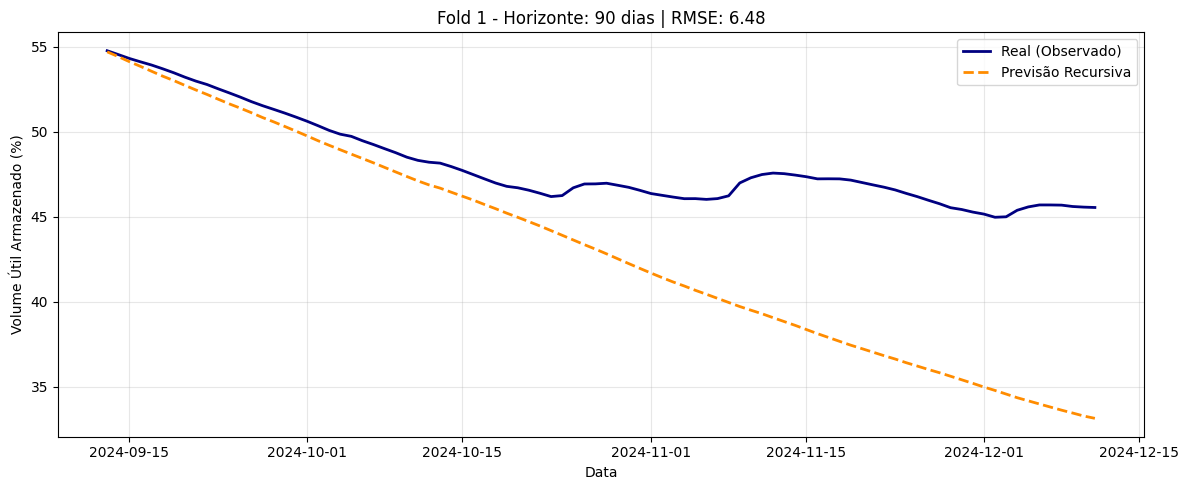

------------------------------
Fold 2: Treino até 2024-12-11 | Teste de 2024-12-12 a 2025-03-11
=== EQUAÇÃO DO MODELO LINEAR ===
Intercepto (Valor Base): -0.2629
------------------------------
              Variável  Peso (Coeficiente)
0             vol_lag1        9.986706e-01
1             vol_diff        2.600806e-02
10  cos(1,freq=YE-DEC)       -1.837953e-02
2            vol_diff2       -1.528150e-02
3              vazao_n        9.277317e-03
4              vazao_j       -8.386056e-03
7        sin(1,730.50)        5.998471e-03
8        cos(1,730.50)       -5.214224e-03
11  sin(2,freq=YE-DEC)        3.577555e-03
12  cos(2,freq=YE-DEC)       -6.506250e-04
9   sin(1,freq=YE-DEC)       -2.723229e-04
6                trend        1.704162e-05
5                const        1.301043e-18
------------------------------

Fórmula aproximada:
Y = -0.2629 + (0.9987 * vol_lag1) + (0.0260 * vol_diff) - (0.0153 * vol_diff2) + (0.0093 * vazao_n) - (0.0084 * vazao_j) + (0.0000 * const) + (0.0000 * t

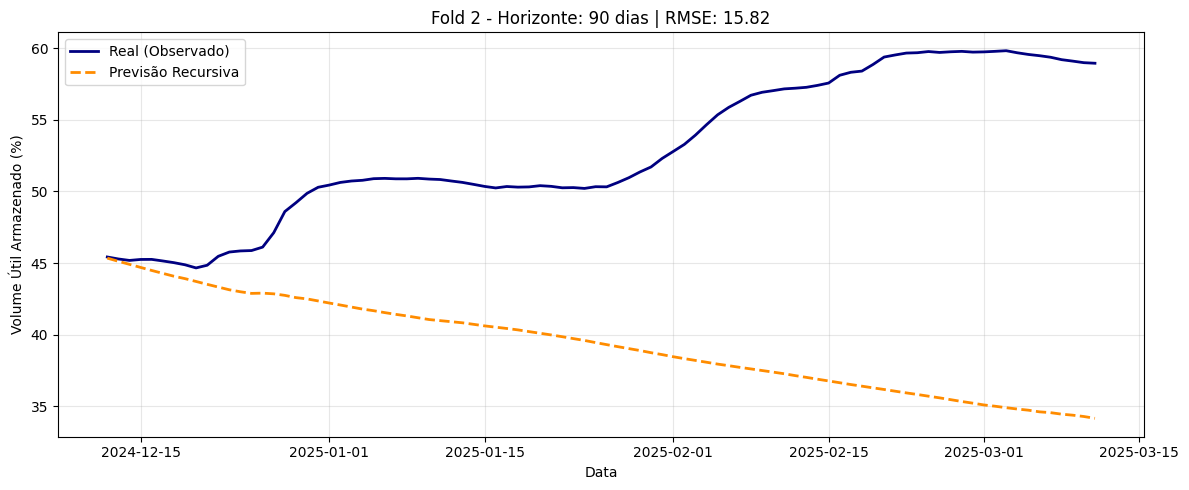

------------------------------
Fold 3: Treino até 2025-03-11 | Teste de 2025-03-12 a 2025-06-09
=== EQUAÇÃO DO MODELO LINEAR ===
Intercepto (Valor Base): -0.2617
------------------------------
              Variável  Peso (Coeficiente)
0             vol_lag1        9.986640e-01
1             vol_diff        2.635834e-02
10  cos(1,freq=YE-DEC)       -1.907478e-02
2            vol_diff2       -1.541126e-02
3              vazao_n        9.271741e-03
4              vazao_j       -8.349941e-03
7        sin(1,730.50)        6.210663e-03
8        cos(1,730.50)       -4.407676e-03
11  sin(2,freq=YE-DEC)        3.028062e-03
12  cos(2,freq=YE-DEC)       -9.302649e-04
9   sin(1,freq=YE-DEC)       -6.126234e-04
6                trend        1.674603e-05
5                const        1.170938e-17
------------------------------

Fórmula aproximada:
Y = -0.2617 + (0.9987 * vol_lag1) + (0.0264 * vol_diff) - (0.0154 * vol_diff2) + (0.0093 * vazao_n) - (0.0083 * vazao_j) + (0.0000 * const) + (0.0000 * t

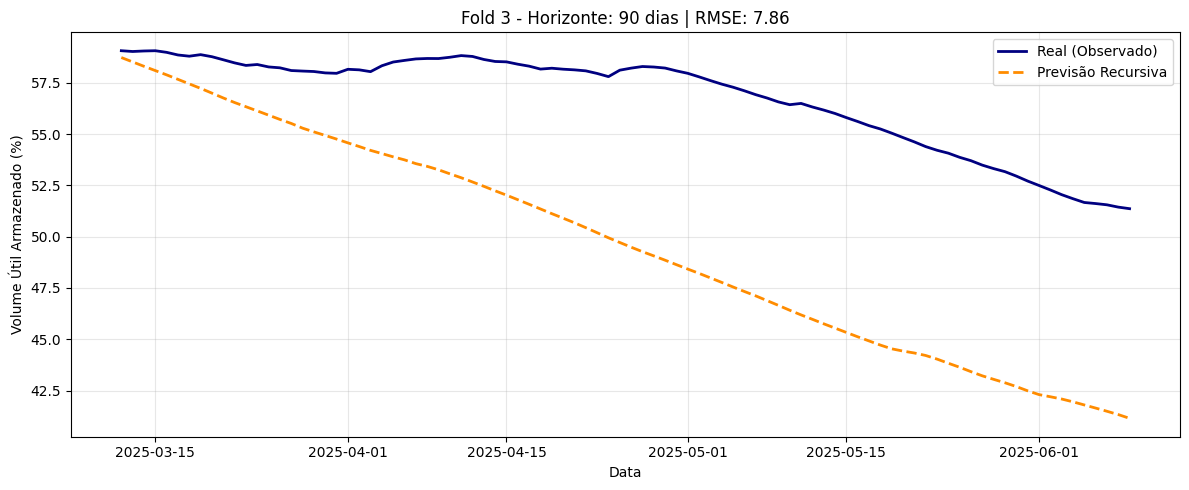

------------------------------
Fold 4: Treino até 2025-06-09 | Teste de 2025-06-10 a 2025-09-07
=== EQUAÇÃO DO MODELO LINEAR ===
Intercepto (Valor Base): -0.2601
------------------------------
              Variável  Peso (Coeficiente)
0             vol_lag1        9.986711e-01
1             vol_diff        2.821551e-02
10  cos(1,freq=YE-DEC)       -1.841397e-02
2            vol_diff2       -1.628007e-02
3              vazao_n        9.260500e-03
4              vazao_j       -8.348017e-03
7        sin(1,730.50)        7.481716e-03
11  sin(2,freq=YE-DEC)        3.805467e-03
8        cos(1,730.50)       -3.664274e-03
9   sin(1,freq=YE-DEC)       -1.991353e-03
12  cos(2,freq=YE-DEC)       -3.713474e-04
6                trend        1.623214e-05
5                const        4.987330e-18
------------------------------

Fórmula aproximada:
Y = -0.2601 + (0.9987 * vol_lag1) + (0.0282 * vol_diff) - (0.0163 * vol_diff2) + (0.0093 * vazao_n) - (0.0083 * vazao_j) + (0.0000 * const) + (0.0000 * t

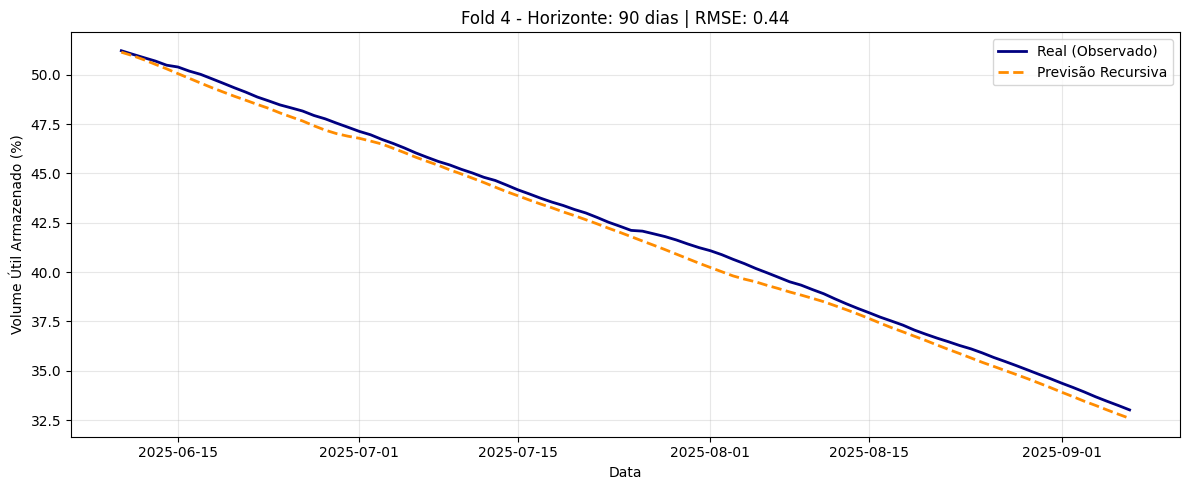

------------------------------
Fold 5: Treino até 2025-09-07 | Teste de 2025-09-08 a 2025-12-06
=== EQUAÇÃO DO MODELO LINEAR ===
Intercepto (Valor Base): -0.2591
------------------------------
              Variável  Peso (Coeficiente)
0             vol_lag1        9.986898e-01
1             vol_diff        2.970400e-02
10  cos(1,freq=YE-DEC)       -1.709115e-02
2            vol_diff2       -1.693591e-02
3              vazao_n        9.251333e-03
7        sin(1,730.50)        8.829200e-03
4              vazao_j       -8.367345e-03
8        cos(1,730.50)       -3.939246e-03
11  sin(2,freq=YE-DEC)        3.218228e-03
9   sin(1,freq=YE-DEC)       -1.785376e-03
12  cos(2,freq=YE-DEC)       -1.139534e-03
6                trend        1.575718e-05
5                const       -1.127570e-17
------------------------------

Fórmula aproximada:
Y = -0.2591 + (0.9987 * vol_lag1) + (0.0297 * vol_diff) - (0.0169 * vol_diff2) + (0.0093 * vazao_n) - (0.0084 * vazao_j) - (0.0000 * const) + (0.0000 * t

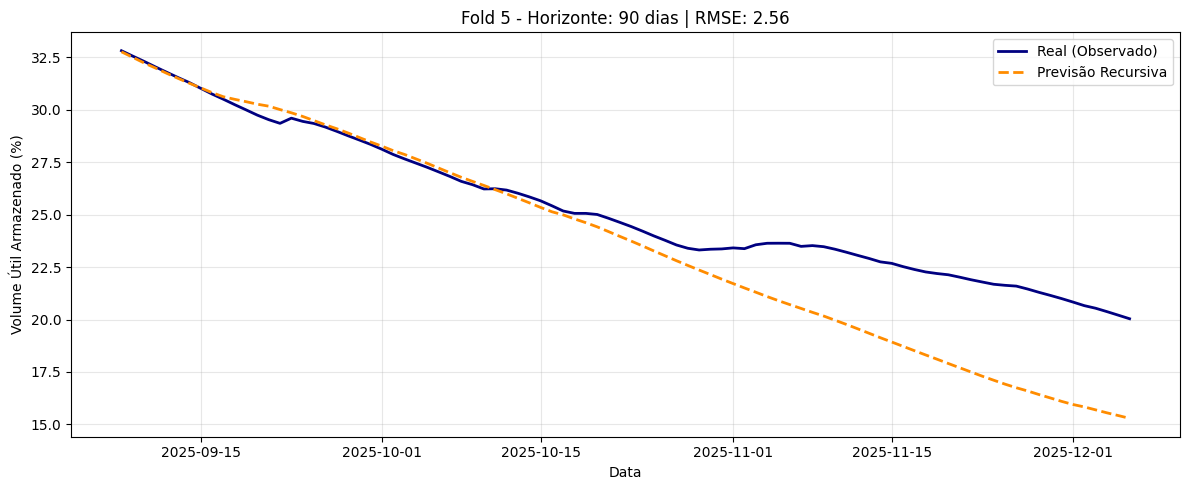

------------------------------

RMSE Médio: 6.6307


In [ ]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import TimeSeriesSplit
from statsmodels.tsa.deterministic import CalendarFourier, DeterministicProcess
from sklearn.metrics import mean_squared_error
import warnings
import matplotlib.pyplot as plt

# Ignore warnings that match the specified criteria
warnings.filterwarnings('ignore', message='.*deprecated.*', category=DeprecationWarning)

# Issue a warning
warnings.warn('This is a deprecated feature', DeprecationWarning)

# --- 1. CONFIGURAÇÃO E DADOS ---
nome_coluna_volume = "Volume Útil Armazenado (%)"
nome_coluna_vazao_natural = "Vazão Natural (m³/s)"
nome_coluna_vazao_jusante = "Vazão Jusante (m³/s)"

df = import_dataframe()
df[(df['Data']<='2014-03-01')|(df['Data']>='2016-02-15')]
df.set_index("Data", inplace=True)
#(k['Data']<='2014-03-01')|(k['Data']>='2016-02-15')

#df = df[df.index >= "2018-01-01"]

VALIDATION_SIZE = 90
LAGS_VAZAO = 2
LAGS_VOLUME = 1

# --- 2. FUNÇÕES AUXILIARES (DESACOPLADAS) ---

def criar_features_deterministicas(index, order=2):
    """Cria X para sazonalidade e tendência (usado pelos modelos lineares de vazão)."""
    fourier = CalendarFourier(freq="YE", order=order)
    dp = DeterministicProcess(
        index=index,
        constant=True,
        order=1, # Tendência linear
        seasonal=False,
        additional_terms=[fourier],
        drop=True,
    )
    return dp.in_sample()

def criar_features_deterministicas_volume(index):
    dp = DeterministicProcess(
        index=index,
        constant=True, order=1,
        additional_terms=[
            Fourier(period=365.25 * 2, order=1),
            CalendarFourier(freq="YE", order=2)
        ],
        drop=True
    )
    return dp.in_sample()

def criar_lags(series, lags):
    """Cria DataFrame com lags para treino."""
    df_lags = pd.DataFrame(index=series.index)
    for lag in range(1, lags + 1):
        df_lags[f'lag_{lag}'] = series.shift(lag)
    return df_lags

def treinar_modelo_hibrido_vazao(y_train, modelo_trend, modelo_resid, lags):
    """
    Treina o combo: Modelo Linear (Tendência) + Modelo ML (Resíduos Lags).
    Retorna os modelos treinados e os últimos resíduos para iniciar o loop de teste.
    """
    # 1. Features Determinísticas
    X_trend = criar_features_deterministicas(y_train.index)
    
    # 2. Fit Modelo Tendência
    modelo_trend.fit(X_trend, y_train)
    y_pred_trend = modelo_trend.predict(X_trend)
    y_pred_trend = pd.Series(y_pred_trend, index=y_train.index)
    
    # 3. Calcular Resíduos
    residuos = y_train - y_pred_trend
    
    # 4. Criar Lags dos Resíduos para o Modelo 2
    X_resid = criar_lags(residuos, lags).dropna()
    y_resid_target = residuos.loc[X_resid.index]
    
    # 5. Fit Modelo Resíduo
    modelo_resid.fit(X_resid, y_resid_target)
    
    # Retorna modelos e os ultimos dados de residuos para servir de 'semente' no teste
    last_residuals = residuos.tail(lags).values
    
    return modelo_trend, modelo_resid, last_residuals

def treinar_modelo_volume(df_train, col_vol, col_vn, col_vj, model_vol):
    y = df_train[col_vol]
    
    X_dynamic = pd.DataFrame(index=df_train.index)
    X_dynamic['vol_lag1'] = df_train[col_vol].shift(1)
    
    # --- NOVAS FEATURES ---
    # 1ª Derivada: Volume(t-1) - Volume(t-2)
    X_dynamic['vol_diff'] = df_train[col_vol].shift(1) - df_train[col_vol].shift(2)
    
    # 2ª Derivada: (Vol(t-1) - Vol(t-2)) - (Vol(t-2) - Vol(t-3))
    # Basicamente: diff(t-1) - diff(t-2)
    X_dynamic['vol_diff2'] = (df_train[col_vol].shift(1) - df_train[col_vol].shift(2)) - \
                             (df_train[col_vol].shift(2) - df_train[col_vol].shift(3))
    # ----------------------

    X_dynamic['vazao_n'] = df_train[col_vn] 
    X_dynamic['vazao_j'] = df_train[col_vj] 
    
    X_trend = criar_features_deterministicas_volume(df_train.index)
    
    X_full = pd.concat([X_dynamic, X_trend], axis=1).dropna()
    y_train = y.loc[X_full.index]
    
    model_vol.fit(X_full, y_train)
    return model_vol, X_full


def mostrar_equacao_linear(modelo, nomes_colunas):
    # 1. Pega os coeficientes e o intercepto
    coeficientes = modelo.coef_
    intercepto = modelo.intercept_
    
    # 2. Cria um DataFrame para facilitar a leitura
    df_params = pd.DataFrame({
        'Variável': nomes_colunas,
        'Peso (Coeficiente)': coeficientes
    })
    
    # 3. Ordena pelo peso absoluto (para ver o que impacta mais)
    df_params['Impacto Absoluto'] = df_params['Peso (Coeficiente)'].abs()
    df_params = df_params.sort_values(by='Impacto Absoluto', ascending=False).drop(columns='Impacto Absoluto')
    
    print("=== EQUAÇÃO DO MODELO LINEAR ===")
    print(f"Intercepto (Valor Base): {intercepto:.4f}")
    print("-" * 30)
    print(df_params)
    print("-" * 30)
    
    # 4. Monta a string da equação visualmente
    equacao_str = f"Y = {intercepto:.4f}"
    for feat, coef in zip(nomes_colunas, coeficientes):
        sinal = "+" if coef >= 0 else "-"
        equacao_str += f" {sinal} ({abs(coef):.4f} * {feat})"
    
    print("\nFórmula aproximada:")
    print(equacao_str)


# --- 3. LOOP DE VALIDAÇÃO (TIME SERIES SPLIT) ---

tscv = TimeSeriesSplit(n_splits=5, test_size=VALIDATION_SIZE)

resultados = []

print("Iniciando Validação Cruzada...\n")

for fold, (train_idx, test_idx) in enumerate(tscv.split(df)):
    
    # Separação dos dados
    df_train = df.iloc[train_idx]
    df_test = df.iloc[test_idx]
    
    print(f"Fold {fold+1}: Treino até {df_train.index[-1].date()} | Teste de {df_test.index[0].date()} a {df_test.index[-1].date()}")

    # =================================================================
    # ETAPA 1: TREINAMENTO (Usando apenas dados de Treino)
    # =================================================================
    
    # --- A. Treinar Vazão Natural (Híbrido) ---
    model_trend_n = Lasso(alpha=0.1)
    model_resid_n = KNeighborsRegressor(n_neighbors=5)
    
    m_trend_n, m_resid_n, last_resids_n = treinar_modelo_hibrido_vazao(
        df_train[nome_coluna_vazao_natural], model_trend_n, model_resid_n, LAGS_VAZAO
    )
    
    # --- B. Treinar Vazão Jusante (Híbrido) ---
    model_trend_j = LinearRegression()
    model_resid_j = RandomForestRegressor(n_estimators=50, random_state=42)
    
    m_trend_j, m_resid_j, last_resids_j = treinar_modelo_hibrido_vazao(
        df_train[nome_coluna_vazao_jusante], model_trend_j, model_resid_j, LAGS_VAZAO
    )
    
    # --- C. Treinar Modelo de Volume ---
    # No treino, o modelo aprende a relação: Vol_t = f(Vol_t-1, Vn_t_real, Vj_t_real)
    model_volume = LinearRegression()
    #model_volume = MLPRegressor()
    model_volume, X_full_eq = treinar_modelo_volume(
        df_train, nome_coluna_volume, nome_coluna_vazao_natural, nome_coluna_vazao_jusante, model_volume
    )
    mostrar_equacao_linear(model_volume, X_full_eq.columns)

    # =================================================================
    # ETAPA 2: PREVISÃO RECURSIVA (Passo a passo no Teste)
    # =================================================================
    
    # Prepara as features determinísticas para TODO o período de teste (pois sabemos as datas)
    X_trend_test_n = criar_features_deterministicas(df_test.index)
    X_trend_test_j = criar_features_deterministicas(df_test.index)
    X_trend_test_v = criar_features_deterministicas_volume(df_test.index)
    
    # Inicializa históricos para a recursão
    hist_resid_n = list(last_resids_n)
    hist_resid_j = list(last_resids_j)
    
    # --- MUDANÇA AQUI: BUFFER DE VOLUME ---
    # Precisamos dos ultimos 3 dias para calcular a 2ª derivada inicial
    # [t-3, t-2, t-1]
    buffer_vols = list(df_train[nome_coluna_volume].tail(3).values)
    
    preds_volume = []
    preds_vn = []
    preds_vj = []
    # Nomes das colunas de lag (para criar o DF certinho e calar o warning)
    cols_lags = [f'lag_{k}' for k in range(1, LAGS_VAZAO + 1)]
    
    # LOOP DIA A DIA (Aqui acontece a mágica recursiva)
    for i in range(len(df_test)):
        current_date = df_test.index[i]
        idx_atual = [df_test.index[i]]
        
        # --- 1. Prever Vazão Natural ---
        # Parte 1: Tendência (Determinística)
        trend_val_n = m_trend_n.predict(X_trend_test_n.iloc[[i]])[0]
        # Resíduo: CRIAR DATAFRAME COM NOMES DE COLUNAS
        vals_lags_n = np.array(hist_resid_n[-LAGS_VAZAO:][::-1])
        df_feat_resid_n = pd.DataFrame([vals_lags_n], columns=cols_lags, index=idx_atual)
        # Parte 2: Resíduo (Baseado nos lags anteriores previstos ou calculados)
        # Monta array de features [lag_1, lag_2] (invertendo a lista para ficar t-1, t-2)
        resid_pred_n = m_resid_n.predict(df_feat_resid_n)[0]
        
        # Valor Final
        y_pred_n = trend_val_n + resid_pred_n
        preds_vn.append(y_pred_n)
        
        # Atualiza histórico de resíduos (Assumimos que o resíduo "real" é o predito para continuar o loop s/ dados futuros)
        # Opcional: Se quiser atualizar com erro zero (puro autoregressivo), apenas appenda o predito.
        hist_resid_n.append(resid_pred_n) 
        
        # --- 2. Prever Vazão Jusante ---
        trend_val_j = m_trend_j.predict(X_trend_test_j.iloc[[i]])[0]
        vals_lags_j = np.array(hist_resid_j[-LAGS_VAZAO:][::-1])
        df_feat_resid_j = pd.DataFrame([vals_lags_j], columns=cols_lags, index=idx_atual)
        resid_pred_j = m_resid_j.predict(df_feat_resid_j)[0]
        
        y_pred_j = trend_val_j + resid_pred_j
        preds_vj.append(y_pred_j)
        hist_resid_j.append(resid_pred_j)
        
        # --- 3. Prever Volume ---
        # Features: [Vol_lag1, Vazao_N_pred, Vazao_J_pred]
        # Parte Dinâmica (calculada agora)
        # Recupera valores do buffer
        vol_t_1 = buffer_vols[-1] # Ontem
        vol_t_2 = buffer_vols[-2] # Anteontem
        vol_t_3 = buffer_vols[-3] # Ante-anteontem
        
        # Calcula as derivadas
        feat_diff = vol_t_1 - vol_t_2
        feat_diff_prev = vol_t_2 - vol_t_3
        feat_diff2 = feat_diff - feat_diff_prev
        
        df_dynamic = pd.DataFrame({
            'vol_lag1':  [vol_t_1],
            'vol_diff':  [feat_diff],  # Nova feature
            'vol_diff2': [feat_diff2], # Nova feature
            'vazao_n':   [y_pred_n],
            'vazao_j':   [y_pred_j]
        }, index=idx_atual)
        
        # Parte Estática (já calculada antes, pegamos a linha 'i')
        # CORREÇÃO CRÍTICA: troquei iloc[[1]] por iloc[[i]]
        df_static = X_trend_test_v.iloc[[i]] 
        
        # Concatenar (Pandas alinha tudo e mantém os nomes das colunas originais)
        X_vol_input = pd.concat([df_dynamic, df_static], axis=1)

        
        vol_pred = model_volume.predict(X_vol_input)[0]
        preds_volume.append(vol_pred)
        
        # Atualiza o last_vol para o próximo passo ser o volume predito agora
        # --- ATUALIZA O BUFFER ---
        buffer_vols.append(vol_pred) # Adiciona o novo previsto no fim
        buffer_vols.pop(0)           # Remove o mais antigo (desliza a janela)

    # =================================================================
    # ETAPA 3: AVALIAÇÃO
    # =================================================================
    y_true = df_test[nome_coluna_volume]
    rmse = np.sqrt(mean_squared_error(y_true, preds_volume))
    mae = np.mean(np.abs(y_true - preds_volume))
    resultados.append(rmse)
    print(f"RMSE Fold {fold+1}: {rmse:.4f}")
    print(f"MAE Fold {fold+1}: {mae:.4f}")
    print(model_volume.coef_)
    print("-" * 30)
    
    # === PLOT DE CADA FOLD ===
    plt.figure(figsize=(12, 5))
    plt.plot(y_true.index, y_true, label='Real (Observado)', color='navy', linewidth=2)
    plt.plot(y_true.index, preds_volume, label='Previsão Recursiva', color='darkorange', linestyle='--', linewidth=2)
    
    plt.title(f'Fold {fold+1} - Horizonte: {VALIDATION_SIZE} dias | RMSE: {rmse:.2f}')
    plt.xlabel('Data')
    plt.ylabel(nome_coluna_volume)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show() # Exibe o gráfico antes de passar para o próximo fold
    
    print("-" * 30)

print(f"\nRMSE Médio: {np.mean(resultados):.4f}")